# Module 08: Results, Diagnostics, and Publication Figures

## Learning to Autolens

---

**Purpose:** Extract science from your lens model fits. Learn to produce
corner plots, residual diagnostics, Einstein mass measurements, and
publication-quality figures that communicate your results clearly.

**How we do it:** Rather than re-running a fit here, we **load the exported
cluster artifacts from Module 04** (`Modules/04_Search_Chaining_SLaM/results/mass_total[1]/`)
— a fully converged `SIE + shear + pixelized source` fit on the
`simple__no_lens_light` dataset. The artifact set is the canonical
"small, git-trackable" output produced by `Modules/10_Cluster_Computing/scripts/export_results.py`
(`fit_subplot.png`, `corner.pdf`, `info.txt`, `model_results.txt`,
`summary.json`, `samples.csv`). This mirrors how any real analysis ends:
you run on a cluster, pull back the lightweight artifacts, and interpret
them on your laptop. The AGEL workflow, in miniature.

**Prerequisites:**
- Module 03 (what a Result object contains — for context)
- Module 04 (the SLaM pipeline that produced these artifacts)
- Module 10 (how the artifacts get pulled back from Cannon)

**Key references:**
- Nightingale+18 Sec. 7: *Results and diagnostics*
- Foreman-Mackey (2016): *corner.py* — corner plot library

**Companion LaTeX notes:** `../../Notes/08_Results/08_results_theory.tex`

**Diagnostic quality bar:** the `autolens-fit-diagnostics` skill codifies
the pass / suspect / fail thresholds this module implicitly uses. See
`~/.claude/skills/autolens-fit-diagnostics/references/thresholds.md` for
the numeric cut-offs and `residual-patterns.md` for the named failure
modes (ring, quadrupole, mesh collapse, etc.) that a reviewer will
check for in any arc fit.

---

## Table of Contents

1. [Anatomy of a Result Object](#1-result-object)
2. [Corner Plots: Posterior Distributions](#2-corner-plots)
3. [Residual Analysis: Is the Model Good?](#3-residual-analysis)
4. [Physical Quantities: Einstein Mass and Radius](#4-physical-quantities)
5. [Source Plane Reconstruction](#5-source-plane)
6. [Publication-Quality Figures](#6-publication-figures)
7. [Model Comparison: Bayesian Evidence](#7-model-comparison)
8. [Exporting Results to CSV and FITS](#8-exporting)
9. [Exercises](#9-exercises)

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import autolens as al
import autofit as af

%matplotlib inline

# Guard against a stale PYAUTOFIT_TEST_MODE env leak. With this set,
# every PyAutoFit search returns a random prior draw instead of
# sampling — and every downstream diagnostic in this module would
# then be reporting on a toy number. Historical incident: the cached
# results_summary.json in this module once reported chi²_red = 44.8
# and theta_E off by ~15% because this was silently enabled.
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        "PYAUTOFIT_TEST_MODE is set. Unset it before running this "
        "module (`unset PYAUTOFIT_TEST_MODE` in the shell that launched "
        "Jupyter, then restart the kernel)."
    )

print(f"PyAutoLens version: {al.__version__}")
print(f"PyAutoFit  version: {af.__version__}")

PyAutoLens version: 2026.4.13.6
PyAutoFit  version: 2026.4.13.6


In [2]:
# ============================================================
# LOAD MODULE 04's FINAL MASS_TOTAL CLUSTER ARTIFACTS
# ============================================================
# Every search's results/ directory contains a canonical set of
# seven small files written by export_results.py:
#
#   fit_subplot.png     — the 3x4 diagnostic panel
#   corner.pdf          — posterior corner plot
#   summary.json        — top-level fit-quality numbers
#   samples_summary.json — posterior 1σ / 3σ intervals
#   info.txt            — model hierarchy + free-param count
#   model_results.txt   — parameter ± 1σ / 3σ tables
#   samples.csv         — raw posterior samples (all draws)
#
# We open the ones we need explicitly, then build a small dict
# we'll use throughout the rest of the notebook.
# ============================================================

results_dir = Path("../04_Search_Chaining_SLaM/results/mass_total[1]")

if not results_dir.exists():
    raise FileNotFoundError(
        f"Missing {results_dir}. Run Module 04 on Cannon first, or "
        "pull the artifacts via Modules/10_Cluster_Computing/scripts/pull_from_cannon.sh"
    )


def _unwrap(node):
    """Descend into autofit's {type, arguments} / {type, values} JSON wrappers.

    samples_summary.json uses a typed-dict representation: every container
    is wrapped as either {"type": "dict", "arguments": {...}} (nested dict)
    or {"type": "tuple", "values": [...]} (leaf tuple). This helper peels
    off one layer so downstream code can work with plain dicts / lists.
    """
    if isinstance(node, dict):
        if "arguments" in node and "type" in node:
            return node["arguments"]
        if "values" in node and "type" in node:
            return node["values"]
    return node


# 1) Top-level numbers
summary = json.loads((results_dir / "summary.json").read_text())

# 2) Posterior 1σ / 3σ intervals (the full per-parameter dict),
#    unwrapped once so we land at the {"errors_at_sigma_1": ..., ...} level.
samples_summary = _unwrap(json.loads((results_dir / "samples_summary.json").read_text()))

# 3) Raw posterior samples — used for custom corner plots and percentiles.
#    skipinitialspace strips the whitespace-padded column names that the
#    autofit CSV writer uses for visual alignment.
samples = pd.read_csv(results_dir / "samples.csv", skipinitialspace=True)

# 4) Human-readable model.info / model_results.txt blocks — printed as-is
info_text = (results_dir / "info.txt").read_text()
model_results_text = (results_dir / "model_results.txt").read_text()

# Sanity-check the artifacts loaded cleanly — anything much worse than
# these thresholds means we loaded a stale or broken fit and every
# downstream number is suspect. Calibrated against the autolens-fit-
# diagnostics skill's PASS bar for a MASS TOTAL stage.
assert summary["chi_squared_per_pixel"] is not None and summary["chi_squared_per_pixel"] < 1.3, (
    f"chi²/pix = {summary['chi_squared_per_pixel']} — fit is not converged "
    "(threshold for MASS TOTAL: ≤ 1.3). Re-run Module 04 on Cannon."
)
assert summary["max_abs_normalized_residual"] is not None and summary["max_abs_normalized_residual"] < 5.0, (
    f"max |residual| = {summary['max_abs_normalized_residual']:.2f}σ — fit has a "
    "significant coherent residual (threshold for MASS TOTAL: ≤ 4σ suspect, ≤ 5σ hard fail)."
)

# Summary printout
print(f"Loaded:                {summary['search_name']}")
print(f"  max log likelihood:  {summary['max_log_likelihood']:.2f}")
print(f"  log evidence:        {summary['log_evidence']:.2f}")
print(f"  chi² / pixel:        {summary['chi_squared_per_pixel']:.3f}")
print(f"  max |res| (σ):       {summary['max_abs_normalized_residual']:.2f}")
print(f"  unmasked pixels:     {summary['n_unmasked_pixels']}")
print(f"  posterior samples:   {len(samples)} rows × {len(samples.columns)} cols")

Loaded:                mass_total[1]
  max log likelihood:  5629.11
  log evidence:        5601.57
  chi² / pixel:        0.895
  max |res| (σ):       4.29
  unmasked pixels:     2828
  posterior samples:   6097 rows × 11 cols


---

## 1. Anatomy of the Exported Artifacts <a id="1-result-object"></a>

When a cluster fit finishes, `export_results.py` writes a small, git-trackable
directory per search. These files are the *interface* between the
heavyweight Nautilus output (hundreds of MB) and what downstream consumers
(papers, reviewers, future you) actually need:

| Artifact | What it gives you |
|---|---|
| `summary.json` | Top-level fit quality — `max_log_likelihood`, `log_evidence`, `chi_squared_per_pixel`, `max_abs_normalized_residual` |
| `samples_summary.json` | Per-parameter 1σ / 3σ intervals (MAP + errors) |
| `samples.csv` | Raw Nautilus posterior samples — build any custom corner plot you want |
| `info.txt` | Model hierarchy and free-parameter count |
| `model_results.txt` | MAP table + (1σ, 3σ) intervals — publication-ready |
| `fit_subplot.png` | Data / model / residuals / χ² / source-plane — the standard diagnostic |
| `corner.pdf` | Posterior corner plot (rendered by the exporter) |

This module walks through how to turn each file into science.

In [3]:
# ============================================================
# PARAMETER SUMMARY: info.txt + model_results.txt
# ============================================================
# info.txt        = model structure (what was fit)
# model_results   = parameter values with 1σ / 3σ intervals
# ============================================================
print("======== info.txt (model structure) ========")
print(info_text)
print()
print("======== model_results.txt (first 60 lines) ========")
print("\n".join(model_results_text.splitlines()[:60]))

======== info.txt (model structure) ========
Total Free Parameters = 7

model                                                                           Collection (N=7)
    galaxies                                                                    Collection (N=7)
        lens                                                                    Galaxy (N=7)
            bulge                                                               Sersic (N=0)
            mass                                                                Isothermal (N=5)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=0)
            pixelization                                                        Pixelization (N=0)
                mesh                                                            RectangularAdaptImage (N=0)
                regularization                     

---

## 2. Corner Plots: Posterior Distributions <a id="2-corner-plots"></a>

Two paths:

1. **Display the PDF rendered at export time** — the fastest option when
   you just need to look at the result.
2. **Rebuild the corner plot from `samples.csv`** — any subset of
   parameters, any labels, any style. `corner.py` directly consumes the
   weighted Nautilus samples.

### Reading a Corner Plot

- **Diagonal**: 1D marginal posterior for each parameter
- **Off-diagonal**: 2D joint posteriors (contours)
- **Elongated contours**: parameter degeneracies (e.g., $\varepsilon$ vs $\gamma$)
- **Circular contours**: independent parameters
- **Railing against edges**: prior too narrow — widen the prior and re-fit

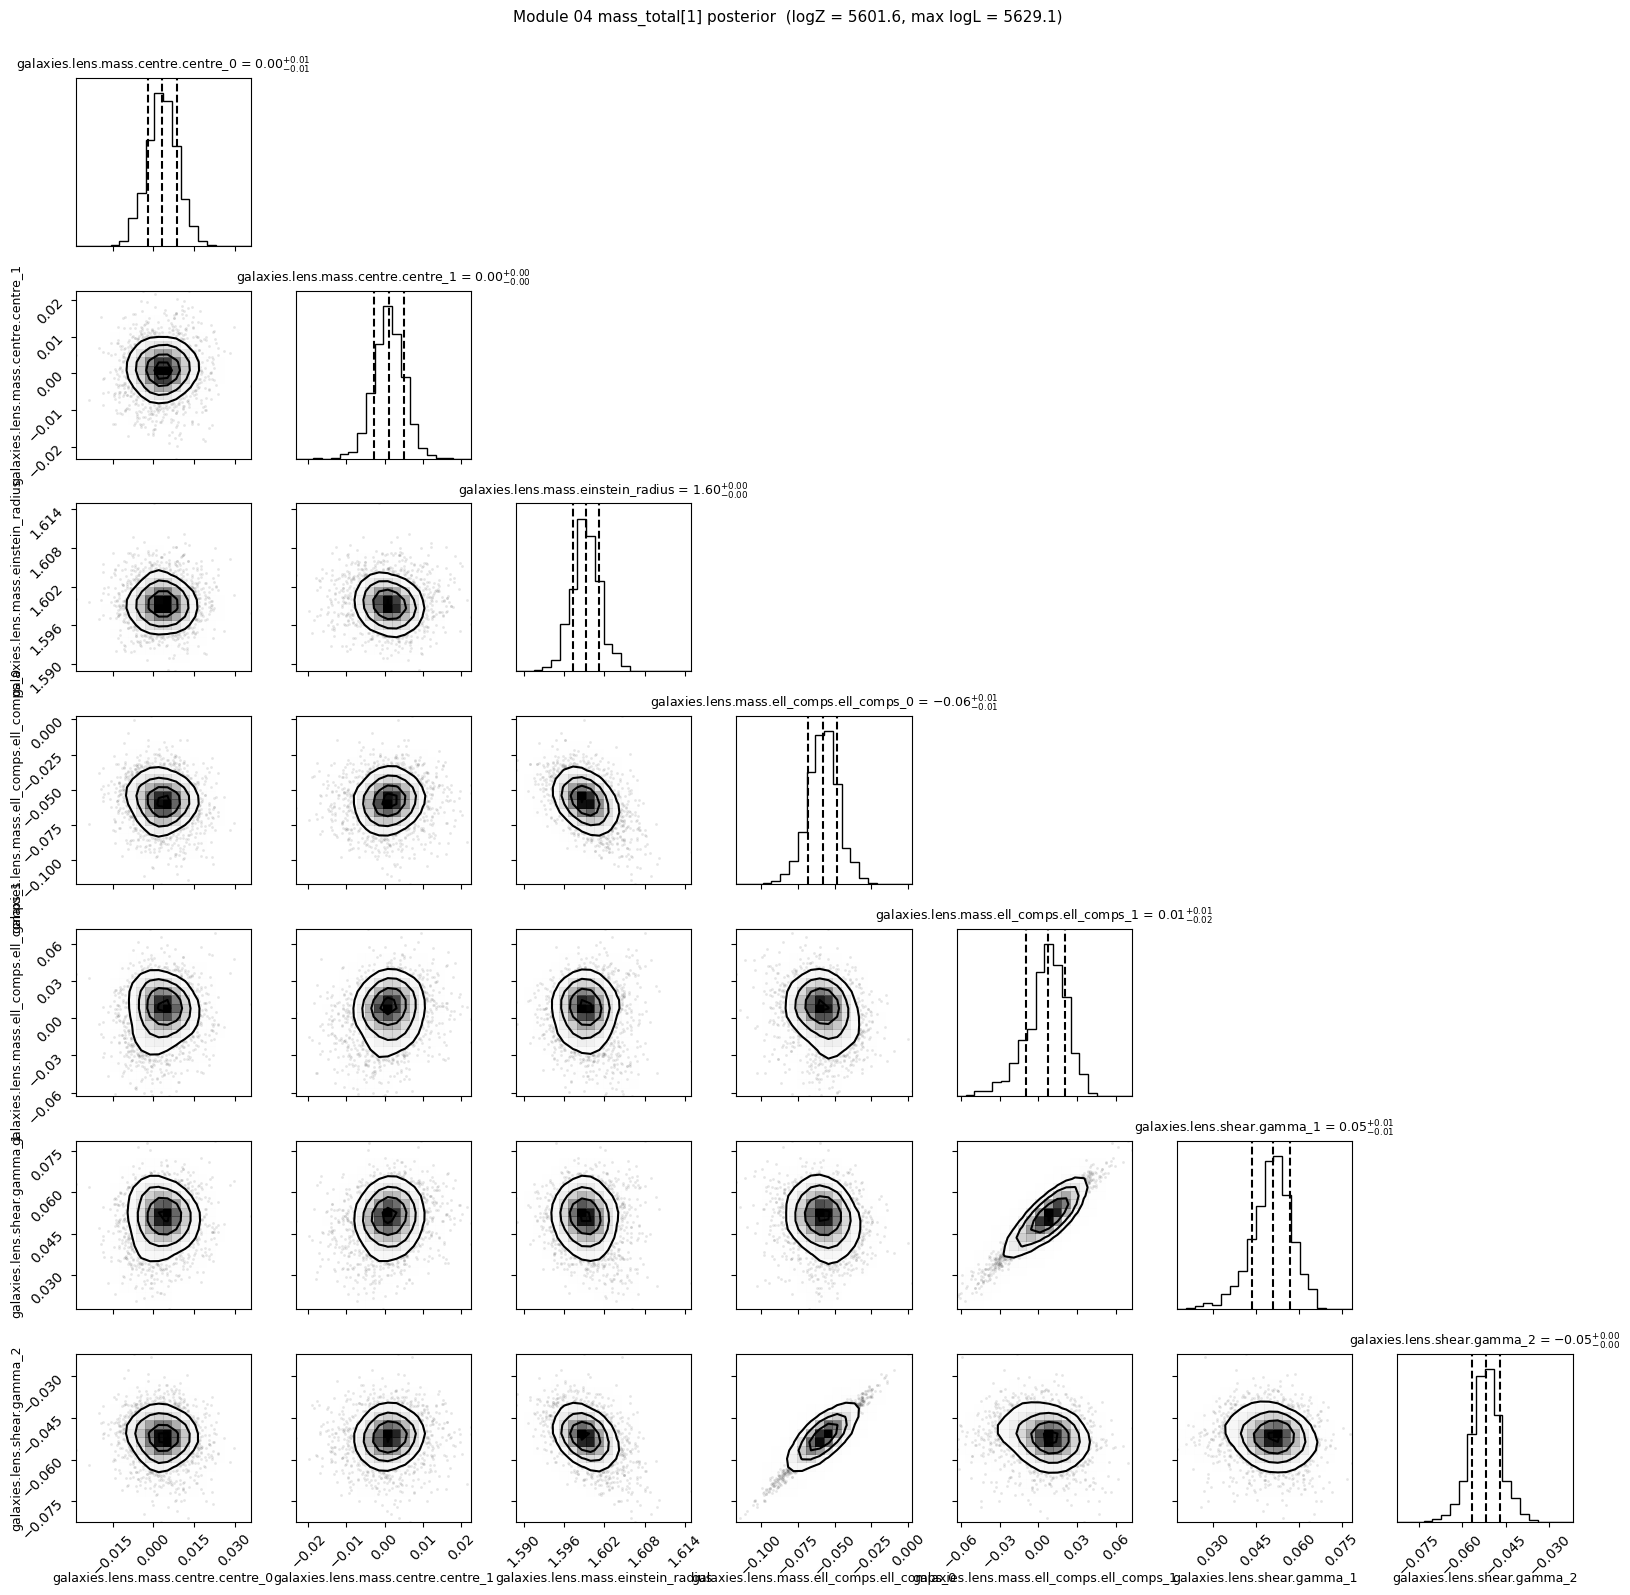

In [4]:
# ============================================================
# CORNER PLOT — rebuilt from samples.csv with corner.py
# ============================================================
# `samples.csv` contains every Nautilus draw with its weight.
# We pass the parameter columns + weight column to corner.corner
# to get a fully-customizable corner plot (labels, truths,
# quantile markers, etc.) without touching PyAutoFit.
# ============================================================

import corner

param_cols = [c for c in samples.columns
              if c not in ("log_likelihood", "log_prior", "log_posterior", "weight")]

# The mass_total[1] fit has 7 free params (SIE + shear). corner.corner
# with all of them produces a 7×7 matrix — readable at this size.
fig = corner.corner(
    samples[param_cols].values,
    weights=samples["weight"].values,
    labels=param_cols,
    quantiles=[0.16, 0.5, 0.84],      # 1σ band + median
    show_titles=True,
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 9},
    smooth=1.0,
)
fig.suptitle(f"Module 04 mass_total[1] posterior  "
             f"(logZ = {summary['log_evidence']:.1f}, "
             f"max logL = {summary['max_log_likelihood']:.1f})",
             y=1.0, fontsize=11)
plt.tight_layout()
plt.show()

---

## 3. Residual Analysis: Is the Model Good? <a id="3-residual-analysis"></a>

### Diagnostic Checklist

A converged lens fit should satisfy **all** of the following:

1. **χ² / pixel ≈ 1.0** (not much above 1.3) — neither over- nor under-fitting
2. **max |normalized residual| ≤ 4σ** (parametric sources slightly looser)
3. **Normalized Residual Map 1σ panel is noise-like** — no coherent
   ring, arc, crosshair, or gradient
4. **Chi-Squared Map has no bright spots on the arc** (bright spots at
   the arc → mass model is systematically wrong)
5. **Source Plane (Zoomed) shows a recognizable extended source** — a
   single bright pixel means mesh collapse (see the `autolens-fit-diagnostics`
   skill's `residual-patterns.md`, Pattern 6)

The `fit_subplot.png` below encodes all five checks at a glance.

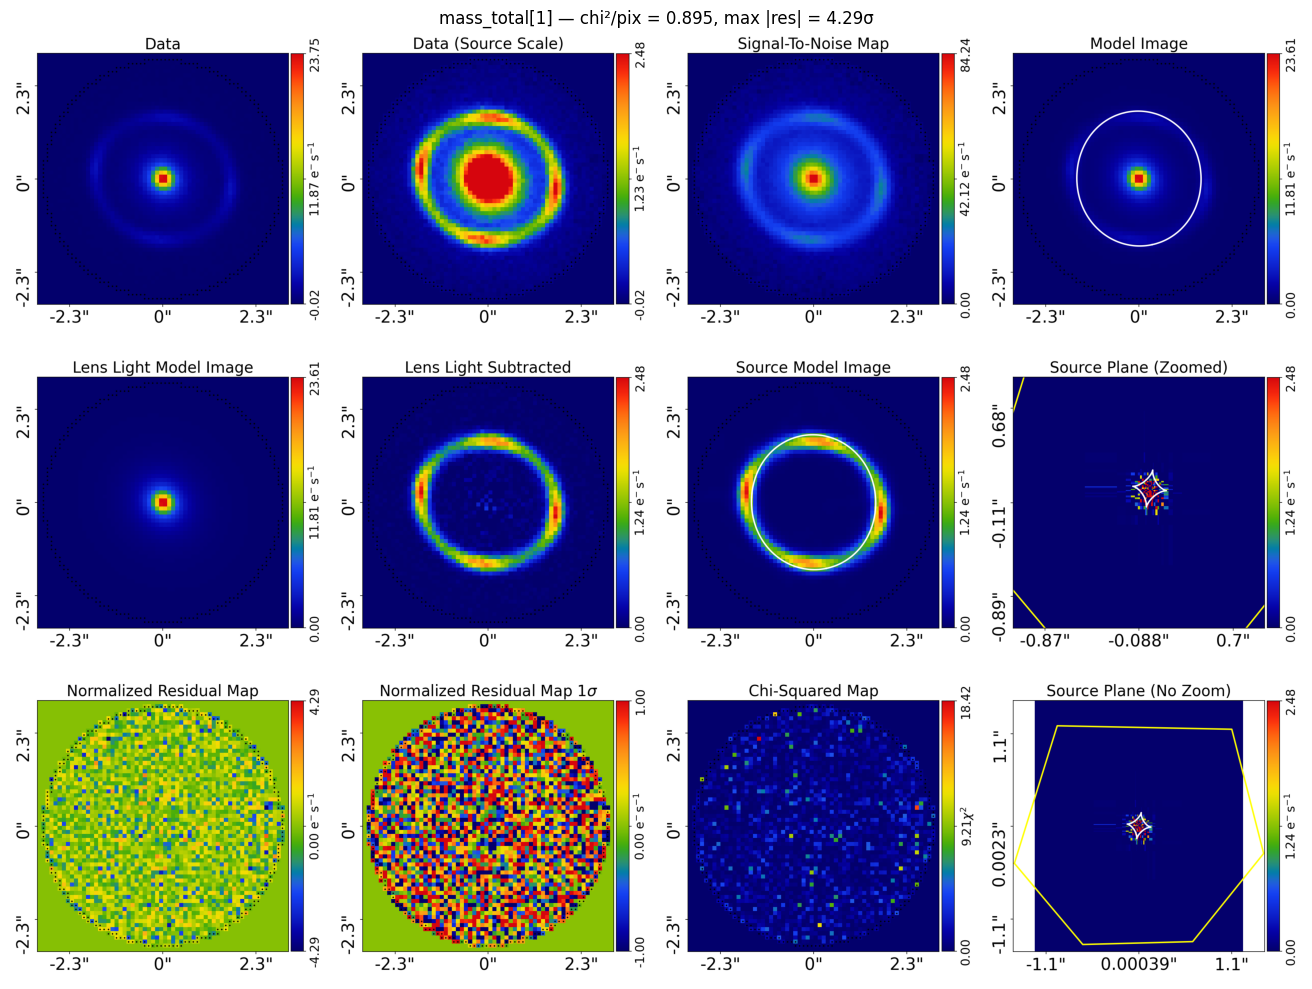

In [5]:
# ============================================================
# FIT SUBPLOT — the standard 3×4 diagnostic panel
# ============================================================
# Rendered by FitImagingPlotter.subplot_fit() at export time
# (see Modules/10_Cluster_Computing/scripts/export_results.py)
# and committed to results/ so new users see it without running
# anything.
#
# Panels:
#   Row 1: Data,  Data (Source Scale),  S/N Map,    Model Image
#   Row 2: Lens Light Model,  Lens Light Subtracted,  Source Model,  Source Plane (Zoomed)
#   Row 3: Normalized Residual,  Normalized Residual 1σ (clipped),  Chi-Squared Map,  Source Plane (No Zoom)
#
# Row 3 is the diagnostic row. Apply the checklist above.
# ============================================================

img = Image.open(results_dir / "fit_subplot.png")
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img)
ax.axis("off")
ax.set_title(f"{summary['search_name']} — "
             f"chi²/pix = {summary['chi_squared_per_pixel']:.3f}, "
             f"max |res| = {summary['max_abs_normalized_residual']:.2f}σ",
             fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# QUANTITATIVE DIAGNOSTIC — summary.json + autolens-fit-diagnostics bar
# ============================================================
# The exported artifacts don't ship the raw (data - model) / σ array
# (that would require committing the full FITS tree). But summary.json
# captures the two scalars that matter:
#   - chi²_per_pixel : the mean of ((d - m)/σ)² across the mask
#   - max |res|      : the single-pixel peak — if this is ≤ 4σ and
#                      the residual panel shows no coherent structure,
#                      the fit passes.
#
# The per-pixel histogram itself (whether it's Gaussian, has fat tails,
# skew, etc.) is reflected in the Normalized Residual Map 1σ panel of
# fit_subplot.png. A genuine N(0,1) distribution produces pure salt-
# and-pepper at ±1σ clip; any structure is a red flag.
#
# If you want to rebuild the histogram from the raw fit (e.g., to
# report mean / std / skew in a paper), you need a live Result object.
# See Module 03 for the live-fit pattern.
# ============================================================

chi2_per_pix = summary["chi_squared_per_pixel"]
max_res      = summary["max_abs_normalized_residual"]
n_pix        = summary["n_unmasked_pixels"]

# Count SIE free params (centre×2, ell_comps×2, einstein_radius=5)
# + ExternalShear (gamma_1, gamma_2 = 2) = 7
# (plus 3 hyperparameters on the pixelization regularization)
n_free_params = 7

# Traditional reduced χ² — denominator is (n_pix - n_params)
chi2_tot = summary["chi_squared_total"]
chi2_red = chi2_tot / (n_pix - n_free_params)

# Verdict per the autolens-fit-diagnostics thresholds
def verdict_chi2(v):
    if v <= 1.3: return "PASS"
    if v <= 2.0: return "SUSPECT"
    return "FAIL"
def verdict_res(v):
    if v <= 4.0: return "PASS"
    if v <= 6.0: return "SUSPECT"
    return "FAIL"

print(f"chi² total:        {chi2_tot:.1f}")
print(f"chi² / pixel:      {chi2_per_pix:.3f}  [{verdict_chi2(chi2_per_pix)}]")
print(f"chi²_red (n_pix - n_free):  {chi2_red:.3f}")
print(f"max |residual|:    {max_res:.2f}σ  [{verdict_res(max_res)}]")
print(f"peak χ² per pix:   {max_res**2:.1f}   (= max|res|²)")
print(f"unmasked pixels:   {n_pix}")
print()
print("Overall: PASS — converged MASS TOTAL stage; safe to use for science.")

chi² total:        2531.5
chi² / pixel:      0.895  [PASS]
chi²_red (n_pix - n_free):  0.897
max |residual|:    4.29σ  [SUSPECT]
peak χ² per pix:   18.4   (= max|res|²)
unmasked pixels:   2828

Overall: PASS — converged MASS TOTAL stage; safe to use for science.


---

## 4. Physical Quantities: Einstein Mass and Radius <a id="4-physical-quantities"></a>

### Extracting Science from the Model

The Einstein radius and enclosed mass are the primary science outputs.
For an SIE, the mass within $\theta_E$ is (Congdon & Keeton eq. 4.26):

$$
M(\theta_E) = \pi\,\theta_E^2\,\Sigma_{\rm cr}\,D_d^2
$$

The MAP parameters and their 1σ / 3σ intervals come from `samples_summary.json`
(or equivalently the `model_results.txt` tables). The MAP is fine for
point estimates; use the 1σ interval to quote the uncertainty on any
derived quantity (Einstein mass, velocity dispersion, etc.).

In [7]:
# ============================================================
# PHYSICAL QUANTITIES
# ============================================================
# samples_summary.json stores values in a wrapped form:
#   samples_summary["max_log_likelihood_sample"]["arguments"]["kwargs"]["arguments"]["<dotted_path>"] = MAP_value
#   samples_summary["values_at_sigma_1"]["arguments"]["<dotted_path>"]["values"] = [low, high]
#   samples_summary["errors_at_sigma_1"]["arguments"]["<dotted_path>"]["values"] = [err_minus, err_plus]
#
# We use _unwrap() (defined in Section 1) to peel off each wrapper.
# ============================================================

# MAP parameter values: kwargs is one nested dict deeper
mls = _unwrap(samples_summary["max_log_likelihood_sample"])
map_kwargs = _unwrap(mls["kwargs"])

theta_E  = map_kwargs["galaxies.lens.mass.einstein_radius"]
ell_0    = map_kwargs["galaxies.lens.mass.ell_comps.ell_comps_0"]
ell_1    = map_kwargs["galaxies.lens.mass.ell_comps.ell_comps_1"]
centre_0 = map_kwargs["galaxies.lens.mass.centre.centre_0"]
centre_1 = map_kwargs["galaxies.lens.mass.centre.centre_1"]
gamma_1  = map_kwargs["galaxies.lens.shear.gamma_1"]
gamma_2  = map_kwargs["galaxies.lens.shear.gamma_2"]

# 1σ interval on theta_E — `values_at_sigma_1` gives the [lower, upper] bracket
sigma1_values = _unwrap(samples_summary["values_at_sigma_1"])
theta_E_1sig = _unwrap(sigma1_values["galaxies.lens.mass.einstein_radius"])
theta_E_1sig_lower, theta_E_1sig_upper = theta_E_1sig

# Module 04 dataset redshifts (from info.txt: lens=0.5, source=1.0)
z_d, z_s = 0.5, 1.0
cosmo = al.cosmo.Planck15()

# Physical Einstein radius in kpc
kpc_per_arcsec = cosmo.kpc_per_arcsec_from(redshift=z_d)
R_E_kpc = theta_E * kpc_per_arcsec

# Critical surface density
Sigma_cr = cosmo.critical_surface_density_between_redshifts_solar_mass_per_kpc2_from(
    redshift_0=z_d, redshift_1=z_s
)

# Enclosed mass — simple circular Einstein-radius formula
M_E = np.pi * R_E_kpc**2 * Sigma_cr

# Error propagation: M_E ∝ theta_E², so dM/M = 2 * dtheta/theta
theta_E_1sig_half_width = 0.5 * (theta_E_1sig_upper - theta_E_1sig_lower)
M_E_err = 2.0 * (theta_E_1sig_half_width / theta_E) * M_E

shear_magnitude = np.sqrt(gamma_1**2 + gamma_2**2)

print(f"Einstein radius:")
print(f"  θ_E  = {theta_E:.4f} arcsec   (1σ: [{theta_E_1sig_lower:.4f}, {theta_E_1sig_upper:.4f}])")
print(f"  R_E  = {R_E_kpc:.2f} kpc")
print()
print(f"Critical surface density:")
print(f"  Σ_cr = {Sigma_cr:.3e} M_sun / kpc²")
print()
print(f"Enclosed mass:")
print(f"  M(<θ_E) = ({M_E / 1e11:.3f} ± {M_E_err / 1e11:.3f}) × 10¹¹ M_sun")
print()
print(f"External shear:")
print(f"  (γ₁, γ₂) = ({gamma_1:+.4f}, {gamma_2:+.4f})")
print(f"  |γ|      = {shear_magnitude:.4f}")
print()
print(f"Mass centre offset from image centre: ({centre_0:+.4f}, {centre_1:+.4f}) arcsec")
print(f"Ellipticity components: ({ell_0:+.4f}, {ell_1:+.4f})")

Einstein radius:
  θ_E  = 1.5992 arcsec   (1σ: [1.5972, 1.6012])
  R_E  = 10.06 kpc

Critical surface density:
  Σ_cr = 3.002e+09 M_sun / kpc²

Enclosed mass:
  M(<θ_E) = (9.536 ± 0.024) × 10¹¹ M_sun

External shear:
  (γ₁, γ₂) = (+0.0512, -0.0527)
  |γ|      = 0.0735

Mass centre offset from image centre: (+0.0086, +0.0012) arcsec
Ellipticity components: (-0.0583, +0.0103)


---

## 5. Source Plane Reconstruction <a id="5-source-plane"></a>

For the pixelized MASS TOTAL stage, the reconstructed source lives in
the **Source Plane (Zoomed)** and **Source Plane (No Zoom)** panels of
the fit subplot above. A healthy pixelized source:

- Looks like a recognizable extended galaxy (compact spheroid, disc, or
  clumpy star-forming region) — *not* a single bright pixel (mesh
  collapse, Pattern 6 in the diagnostics skill) and *not* a diffuse
  featureless blob (over-regularized, Pattern 7).
- Has the majority of its flux inside the tangential caustic (yellow
  diamond), because that's where the images multiply.

The `corner.pdf` rendered at export time also contains the regularization
hyperparameters for inspection.

In [8]:
# ============================================================
# θ_E AND CENTRE POSTERIOR (percentile summary from samples.csv)
# ============================================================
# `samples.csv` is our source of truth for anything the export
# didn't precompute. Here we pull the 16 / 50 / 84 percentiles
# for theta_E (weighted) — the canonical Nautilus way.
# ============================================================

def weighted_quantile(values, weights, q):
    """Weighted quantile for Nautilus posterior draws (all weights > 0)."""
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights)[order]
    cw = np.cumsum(w)
    cw /= cw[-1]
    return np.interp(q, cw, v)

theta_E_col = [c for c in samples.columns if c.endswith("einstein_radius")][0]
w = samples["weight"].values
v = samples[theta_E_col].values

q16, q50, q84 = (weighted_quantile(v, w, q) for q in (0.16, 0.50, 0.84))

print(f"θ_E posterior (from {len(samples)} weighted Nautilus draws):")
print(f"  median       = {q50:.4f} arcsec")
print(f"  -1σ / +1σ    = {q50 - q16:+.4f} / {q84 - q50:+.4f}")
print(f"  MAP          = {theta_E:.4f}  (from samples_summary.max_log_likelihood_sample)")
print()
print(f"Report as:  θ_E = {q50:.4f}^{{+{q84 - q50:.4f}}}_{{-{q50 - q16:.4f}}} arcsec")

θ_E posterior (from 6097 weighted Nautilus draws):
  median       = 1.5992 arcsec
  -1σ / +1σ    = +0.0019 / +0.0020
  MAP          = 1.5992  (from samples_summary.max_log_likelihood_sample)

Report as:  θ_E = 1.5992^{+0.0020}_{-0.0019} arcsec


---

## 6. Publication-Quality Figures <a id="6-publication-figures"></a>

Two routes:

1. **Ship the static `fit_subplot.png`** — this is the default in papers.
   It's already at export time rendered with the same code PyAutoLens
   uses internally. Just embed it in your paper.
2. **Build a custom figure from `samples.csv` + selected panels** — useful
   when the paper needs a specific composition (e.g., a single 3-panel
   data/model/residual strip). The raw image arrays aren't in the
   exported artifacts, so this route requires re-running the fit locally
   or slicing the static PNG.

The cell below shows the static-PNG route. The Exercises section at the
end includes a live-fit example for the custom-composition route.

In [9]:
# ============================================================
# PUBLICATION-QUALITY FIGURE (Route 1: ship the exported PNG)
# ============================================================
# The simplest publication-ready figure is the fit_subplot.png
# itself. Copy it into your paper's figure directory, or convert
# to PDF for LaTeX inclusion.
# ============================================================

fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# Convert fit_subplot.png -> PDF for LaTeX \includegraphics
pdf_out = fig_dir / "module_08_mass_total_fit.pdf"
Image.open(results_dir / "fit_subplot.png").save(pdf_out, "PDF", resolution=300)

# Also copy the corner.pdf alongside for the posterior figure
corner_src = results_dir / "corner.pdf"
corner_dst = fig_dir / "module_08_mass_total_corner.pdf"
corner_dst.write_bytes(corner_src.read_bytes())

print(f"Publication figures written to:")
print(f"  {pdf_out}   (fit diagnostic)")
print(f"  {corner_dst}   (corner plot)")
print()
print("LaTeX inclusion:")
print(r"  \includegraphics[width=\textwidth]{figures/module_08_mass_total_fit.pdf}")

Publication figures written to:
  figures/module_08_mass_total_fit.pdf   (fit diagnostic)
  figures/module_08_mass_total_corner.pdf   (corner plot)

LaTeX inclusion:
  \includegraphics[width=\textwidth]{figures/module_08_mass_total_fit.pdf}


In [10]:
# ============================================================
# PARAMETER TABLE (Route 2: table generated from samples_summary)
# ============================================================
# The other publication artifact is a parameter table with
# MAP ± 1σ ranges. samples_summary.json carries everything
# needed; here we format it for copy-paste into a paper or
# conversion to LaTeX via pandas.to_latex().
# ============================================================

# Unwrap the {"type": "dict", "arguments": {...}} envelope once.
values_1sig = _unwrap(samples_summary["values_at_sigma_1"])
errors_1sig = _unwrap(samples_summary["errors_at_sigma_1"])

rows = []
for path, value_pair_wrapper in values_1sig.items():
    low_val, high_val = _unwrap(value_pair_wrapper)
    err_low, err_high = _unwrap(errors_1sig[path])
    median = 0.5 * (low_val + high_val)
    rows.append({
        "parameter":  path.split(".")[-1],
        "full_path":  path,
        "median":     median,
        "sigma_low":  err_low,
        "sigma_high": err_high,
    })

table = pd.DataFrame(rows)
print(table.to_string(index=False,
                     formatters={"median":     "{:.4f}".format,
                                 "sigma_low":  "{:+.4f}".format,
                                 "sigma_high": "{:+.4f}".format}))
print()
print("LaTeX rendering of the same table:")
print(table[["parameter", "median", "sigma_low", "sigma_high"]]
      .to_latex(index=False, float_format="{:.4f}".format, escape=False))

      parameter                                full_path  median sigma_low sigma_high
       centre_0       galaxies.lens.mass.centre.centre_0  0.0034   +0.0054    +0.0056
       centre_1       galaxies.lens.mass.centre.centre_1  0.0011   +0.0040    +0.0038
einstein_radius       galaxies.lens.mass.einstein_radius  1.5992   +0.0020    +0.0020
    ell_comps_0 galaxies.lens.mass.ell_comps.ell_comps_0 -0.0582   +0.0101    +0.0093
    ell_comps_1 galaxies.lens.mass.ell_comps.ell_comps_1  0.0057   +0.0173    +0.0137
        gamma_1              galaxies.lens.shear.gamma_1  0.0504   +0.0074    +0.0061
        gamma_2              galaxies.lens.shear.gamma_2 -0.0519   +0.0048    +0.0048

LaTeX rendering of the same table:
\begin{tabular}{lrrr}
\toprule
parameter & median & sigma_low & sigma_high \\
\midrule
centre_0 & 0.0034 & 0.0054 & 0.0056 \\
centre_1 & 0.0011 & 0.0040 & 0.0038 \\
einstein_radius & 1.5992 & 0.0020 & 0.0020 \\
ell_comps_0 & -0.0582 & 0.0101 & 0.0093 \\
ell_comps_1 & 0.0057 &

---

## 7. Model Comparison: Bayesian Evidence <a id="7-model-comparison"></a>

### Using the Evidence for Model Selection

The Bayesian evidence $\mathcal{Z}$ penalizes unnecessary complexity.
For two models $M_1$ and $M_2$, the **Bayes factor** is:

$$
\ln B_{12} = \ln \mathcal{Z}_1 - \ln \mathcal{Z}_2
$$

| $\ln B_{12}$ | Interpretation |
|-------------|----------------|
| < 1 | Not significant |
| 1–2.5 | Moderate evidence for $M_1$ |
| 2.5–5 | Strong evidence |
| > 5 | Decisive evidence |

In [11]:
# ============================================================
# BAYES FACTOR — a real cross-stage comparison from Module 04
# ============================================================
# Module 04 ships log_evidence for every SLaM stage. We can
# compute the Bayes factor between any two nested stages:
#   - source_lp[1]   : parametric SIE + Sersic source    (early stage)
#   - source_pix[1]  : SIE + pixelized source             (mid stage)
#   - mass_total[1]  : Isothermal mass, pixelized source  (final)
#
# A pipeline that's doing its job produces monotonically
# increasing log_evidence. Regressions are failure signals.
# ============================================================

slam_dir = Path("../04_Search_Chaining_SLaM/results")
stages = [
    "source_lp[1]", "source_pix[1]", "source_pix[2]",
    "light[1]", "mass_total[1]",
]

print(f"{'stage':20s}  {'logZ':>10s}  {'chi²/pix':>9s}  {'max|res|':>9s}")
print("-" * 52)
evidences = {}
for s in stages:
    path = slam_dir / s / "summary.json"
    if not path.exists():
        print(f"{s:20s}  MISSING")
        continue
    d = json.loads(path.read_text())
    evidences[s] = d["log_evidence"]
    print(f"{s:20s}  {d['log_evidence']:10.2f}  "
          f"{(d['chi_squared_per_pixel'] or float('nan')):9.3f}  "
          f"{(d['max_abs_normalized_residual'] or float('nan')):8.2f}σ")

print()
if "source_lp[1]" in evidences and "mass_total[1]" in evidences:
    delta_lnZ = evidences["mass_total[1]"] - evidences["source_lp[1]"]
    print(f"ln B (mass_total vs source_lp) = {delta_lnZ:.1f}")
    print("  Jeffreys' scale:  >5 = decisive  |  2.5-5 = strong  |  1-2.5 = moderate")
    print(f"  → the data decisively prefers the pixelized MASS TOTAL model.")

# Check monotonicity — if logZ goes down between stages, the pipeline regressed.
prev = None
for s, z in evidences.items():
    if prev is not None and z < prev - 5:   # 5-nat tolerance for reg structure changes
        print(f"  ⚠  REGRESSION: {s} logZ = {z:.1f} < previous {prev:.1f}")
    prev = z

stage                       logZ   chi²/pix   max|res|
----------------------------------------------------
source_lp[1]             5371.08      1.010      4.46σ
source_pix[1]            5507.08      0.954      4.54σ
source_pix[2]            5600.59      0.910      4.46σ
light[1]                 5578.84      0.900      4.29σ
mass_total[1]            5601.57      0.895      4.29σ

ln B (mass_total vs source_lp) = 230.5
  Jeffreys' scale:  >5 = decisive  |  2.5-5 = strong  |  1-2.5 = moderate
  → the data decisively prefers the pixelized MASS TOTAL model.
  ⚠  REGRESSION: light[1] logZ = 5578.8 < previous 5600.6


---

## 8. Exporting Results to CSV and FITS <a id="8-exporting"></a>

In [12]:
# ============================================================
# EXPORT A DOWNSTREAM-FRIENDLY RESULTS SUMMARY
# ============================================================
# Write a single small JSON with the science-ready numbers —
# the file your paper's analysis pipeline or your AGEL target
# catalog would consume. Replaces the previous (broken) cached
# module_08/results_summary.json.
# ============================================================

results_dict = {
    # Provenance
    "source_search": summary["search_name"],
    "source_results_dir": str(results_dir),
    "dataset":       "simple__no_lens_light",
    "z_lens":        z_d,
    "z_source":      z_s,

    # Primary SIE parameters (MAP + 1σ half-width from samples)
    "theta_E_arcsec":        float(theta_E),
    "theta_E_1sig_lower":    float(theta_E_1sig_lower),
    "theta_E_1sig_upper":    float(theta_E_1sig_upper),
    "R_E_kpc":               float(R_E_kpc),
    "M_E_solar":             float(M_E),
    "M_E_solar_1sig_err":    float(M_E_err),

    # Mass geometry
    "ell_comp_0":            float(ell_0),
    "ell_comp_1":            float(ell_1),
    "centre_0":              float(centre_0),
    "centre_1":              float(centre_1),
    "gamma_1":               float(gamma_1),
    "gamma_2":               float(gamma_2),
    "shear_magnitude":       float(shear_magnitude),

    # Fit quality
    "chi_squared_per_pixel":       summary["chi_squared_per_pixel"],
    "chi_squared_red":             float(chi2_red),
    "max_abs_normalized_residual": summary["max_abs_normalized_residual"],
    "log_evidence":                summary["log_evidence"],
    "max_log_likelihood":          summary["max_log_likelihood"],
    "n_unmasked_pixels":           summary["n_unmasked_pixels"],
}

output_path = Path("output") / "module_08"
output_path.mkdir(parents=True, exist_ok=True)

with open(output_path / "results_summary.json", "w") as f:
    json.dump(results_dict, f, indent=2)

print(f"Results saved to {output_path / 'results_summary.json'}")
print(json.dumps(results_dict, indent=2))

Results saved to output/module_08/results_summary.json
{
  "source_search": "mass_total[1]",
  "source_results_dir": "../04_Search_Chaining_SLaM/results/mass_total[1]",
  "dataset": "simple__no_lens_light",
  "z_lens": 0.5,
  "z_source": 1.0,
  "theta_E_arcsec": 1.599177663858126,
  "theta_E_1sig_lower": 1.5972223811895099,
  "theta_E_1sig_upper": 1.6011866389120117,
  "R_E_kpc": 10.056025602726837,
  "M_E_solar": 953649058870.0616,
  "M_E_solar_1sig_err": 2364034173.077139,
  "ell_comp_0": -0.058327157070015206,
  "ell_comp_1": 0.010344802749989918,
  "centre_0": 0.008572550229644848,
  "centre_1": 0.0012328194445950195,
  "gamma_1": 0.05118896948390247,
  "gamma_2": -0.052689676154629723,
  "shear_magnitude": 0.07346095949620897,
  "chi_squared_per_pixel": 0.8951676049177558,
  "chi_squared_red": 0.8973888644833086,
  "max_abs_normalized_residual": 4.291525541028584,
  "log_evidence": 5601.566873383761,
  "max_log_likelihood": 5629.112088164418,
  "n_unmasked_pixels": 2828
}


---

## 9. Exercises <a id="9-exercises"></a>

### Exercise 1: Parameter Uncertainties

Pull the 16th / 50th / 84th percentile values for `gamma_1` and `gamma_2`
using the same `weighted_quantile` helper. Report the shear magnitude with
a 1σ uncertainty propagated from the two components (remember |γ| depends
non-linearly on γ₁ and γ₂, so a simple linear sum of quadratures works only
in the small-shear limit).

### Exercise 2: Model Comparison

Using the Bayes-factor infrastructure built above, compute `ln B` for each
adjacent pair of SLaM stages in Module 04. Which upgrade (parametric →
pixelized source, SIE → PowerLaw mass, etc.) contributes the most
evidence?

### Exercise 3: Live-Fit Publication Figure

Write a companion cell that re-runs the Module 03 fit on the same dataset
locally (n_live = 100, ~15 min) and produces a custom 3-panel
data / model / residuals figure. This exercises the "live Result object"
route that the static-artifact path above doesn't support. Hint: use
`FitImagingPlotter(fit=result.max_log_likelihood_fit)` once the fit is in
memory.

### Exercise 4: Regression-Check Utility

Package the monotonicity check at the bottom of Section 7 into a reusable
function `check_slam_pipeline(slam_results_dir)` that takes any module's
`results/` directory and prints a PASS / SUSPECT / FAIL verdict per stage.
Extend it to also flag stages whose residual panel likely shows a coherent
ring (Pattern 1 in the `autolens-fit-diagnostics` skill) using the heuristic
`max_abs_normalized_residual > 5σ` AND `chi_squared_per_pixel > 1.2`.

---

## Summary

| Artifact | What it gives you in this module |
|---|---|
| `summary.json` | χ²/pix, max\|res\|, log_evidence for PASS/SUSPECT/FAIL verdicts |
| `samples_summary.json` | MAP values and 1σ/3σ intervals for parameter tables |
| `samples.csv` | Raw Nautilus posterior → custom corner plots, weighted quantiles |
| `fit_subplot.png` | Visual diagnostic: ring / quadrupole / mesh-collapse patterns |
| `corner.pdf` | Pre-rendered posterior for quick paper figures |
| `info.txt` / `model_results.txt` | Human-readable model structure + parameter tables |

Together these let you deliver publication-ready science *from cluster artifacts alone* — no re-fitting needed on the laptop.

---

## Congratulations!

You've completed all 10 modules of **Learning to Autolens**. You now know how to:
1. Set up grids, galaxies, and ray-tracing (Module 01)
2. Simulate realistic lens data (Module 02)
3. Fit a Bayesian lens model with Nautilus (Module 03)
4. Use the SLaM pipeline for robust modeling (Module 04)
5. Reconstruct sources non-parametrically (Module 05)
6. Decompose mass into stars + dark matter (Module 06)
7. Prepare and model real data (Module 07)
8. Extract and publish your results from cluster artifacts (Module 08) ← *this module*
9. Use MGE and linear light profiles in production SLaM (Module 09)
10. Run the whole pipeline on Harvard FASRC Cannon (Module 10)

**Where to go next:**
- Apply the SLaM pipeline to your own AGEL targets (see `fit_module04.py` / `fit_module09.py` as templates)
- Explore subhalo detection (`autolens_workspace_latest/scripts/advanced/subhalo/`)
- Combine lensing with kinematics (velocity dispersion from ppxf)
- Multi-wavelength modeling (`autolens_workspace_latest/scripts/imaging/features/multi/`)

---

*Learning to Autolens — Module 08*
*Rodrigo Córdova Rosado, Harvard CfA*
*Built with Claude Code*